# 04 · VAR Baseline — Multi-step Forecast

**Project:** War Shocks & Global Financial Risk Spillover  
**Model:** Pure VAR, following Diebold & Yilmaz (2009, 2012) and Kumar et al. (2024). War/crisis information is embedded only in the endogenous volatility series, ensuring a fair comparison with LSTM/GRU on identical information sets.

**Outputs:** `outputs/tables/table_var_metrics_h*.xlsx`, `outputs/figures/fig9_var_forecast.png`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore", category=ValueWarning)

from src.data_loader import DATA_PROC_DIR
from src.var_models  import (
    fit_var, rolling_forecast_var_multistep, compute_metrics, 
    compute_metrics_multistep, EQUITY_COLS, HORIZONS
)

FIG_DIR   = os.path.join("..", "outputs", "figures")
TABLE_DIR = os.path.join("..", "outputs", "tables")
os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

TRAIN_START = "2000-01-01"; TRAIN_END = "2018-12-31"
VAL_START   = "2019-01-01"; VAL_END   = "2021-12-31"
TEST_START  = "2022-01-01"; TEST_END  = "2025-12-31"

print("HORIZONS:", HORIZONS)

HORIZONS: [1, 5, 10, 22]


## 1 · Load Volatility Data

In [2]:
vol_df  = pd.read_excel(f"{DATA_PROC_DIR}/rolling_volatility.xlsx",
                index_col=0, parse_dates=True)
war_df  = pd.read_excel(f"{DATA_PROC_DIR}/war_dummies.xlsx",
                index_col=0, parse_dates=True)

vol_clean = vol_df[EQUITY_COLS].dropna()
print(f"vol_clean: {vol_clean.shape}  "
      f"{vol_clean.index[0].date()} ~ {vol_clean.index[-1].date()}")

vol_clean: (5080, 8)  2000-03-15 ~ 2025-12-30


## 2 · Fit VAR on Training Period

AIC lag selection, endogenous = 8 vol series.

In [3]:
vol_train = vol_clean.loc[TRAIN_START:TRAIN_END]
result, selected_lag = fit_var(vol_train, maxlags=10, verbose=True)
print(f"\nTotal params: {result.params.size}")

  AIC selected lag : 5
  Log-likelihood   : 86230.89
  AIC              : -69.52
  N obs used       : 3670

Total params: 328


## 3 · Multi-step Rolling Forecast — Val & Test

Expanding-window VAR for h ∈ {1, 5, 10, 22}.  
At each origin t, VAR is re-estimated on all data before t,  
then h-step-ahead forecast is recorded. This is consistent with  
the multi-horizon evaluation in Kumar et al. (2024) Table 3.

In [4]:
print("=== Validation period ===")
results_val = rolling_forecast_var_multistep(
    vol_clean, VAL_START, VAL_END,
    horizons=HORIZONS, maxlags=10, verbose_step=50
)

print("\n=== Test period ===")
results_test = rolling_forecast_var_multistep(
    vol_clean, TEST_START, TEST_END,
    horizons=HORIZONS, maxlags=10, verbose_step=50
)

=== Validation period ===
VAR multi-step: 2019-01-01 ~ 2021-12-31 | horizons=[1, 5, 10, 22] | origins=594
  50/594  (2019-04-16)
  100/594  (2019-08-01)
  150/594  (2019-11-13)
  200/594  (2020-01-28)
  250/594  (2020-05-13)
  300/594  (2020-07-24)
  350/594  (2020-10-05)
  400/594  (2021-01-21)
  450/594  (2021-05-05)
  500/594  (2021-07-16)
  550/594  (2021-09-27)
  594/594  (2021-12-31)

=== Test period ===
VAR multi-step: 2022-01-01 ~ 2025-12-31 | horizons=[1, 5, 10, 22] | origins=811
  50/811  (2022-04-18)
  100/811  (2022-06-29)
  150/811  (2022-09-09)
  200/811  (2022-12-22)
  250/811  (2023-04-11)
  300/811  (2023-06-22)
  350/811  (2023-09-01)
  400/811  (2023-12-19)
  450/811  (2024-04-08)
  500/811  (2024-06-18)
  550/811  (2024-08-29)
  600/811  (2024-12-12)
  650/811  (2025-04-03)
  700/811  (2025-06-16)
  750/811  (2025-08-27)
  800/811  (2025-12-12)
  811/811  (2025-12-30)


## 4 · Evaluation Metrics

In [5]:
metrics_val  = compute_metrics_multistep(results_val,  label="VAR_Val")
metrics_test = compute_metrics_multistep(results_test, label="VAR_Test")

print("=" * 65)
print("VAR METRICS — Validation (AVERAGE across markets)")
print("=" * 65)
for h in HORIZONS:
    sub = metrics_val[(metrics_val["Horizon"]==h) & (metrics_val["Market"]=="AVERAGE")].iloc[0]
    print(f"  h={h:2d}: MSE={sub['MSE']:.6f}  MAE={sub['MAE']:.4f}  "
          f"RMSE={sub['RMSE']:.4f}  MAPE={sub['MAPE']:.2f}%  DirAcc={sub['Dir_Acc']:.3f}")

print("\n" + "=" * 65)
print("VAR METRICS — Test (AVERAGE across markets)")
print("=" * 65)
for h in HORIZONS:
    sub = metrics_test[(metrics_test["Horizon"]==h) & (metrics_test["Market"]=="AVERAGE")].iloc[0]
    print(f"  h={h:2d}: MSE={sub['MSE']:.6f}  MAE={sub['MAE']:.4f}  "
          f"RMSE={sub['RMSE']:.4f}  MAPE={sub['MAPE']:.2f}%  DirAcc={sub['Dir_Acc']:.3f}")

VAR METRICS — Validation (AVERAGE across markets)
  h= 1: MSE=0.000615  MAE=0.0133  RMSE=0.0246  MAPE=7.75%  DirAcc=0.499
  h= 5: MSE=0.002240  MAE=0.0295  RMSE=0.0466  MAPE=17.42%  DirAcc=0.459
  h=10: MSE=0.005411  MAE=0.0455  RMSE=0.0715  MAPE=26.39%  DirAcc=0.456
  h=22: MSE=0.013895  MAE=0.0704  RMSE=0.1143  MAPE=39.71%  DirAcc=0.482

VAR METRICS — Test (AVERAGE across markets)
  h= 1: MSE=0.000589  MAE=0.0118  RMSE=0.0236  MAPE=7.32%  DirAcc=0.500
  h= 5: MSE=0.002103  MAE=0.0261  RMSE=0.0447  MAPE=16.12%  DirAcc=0.492
  h=10: MSE=0.004064  MAE=0.0393  RMSE=0.0625  MAPE=24.55%  DirAcc=0.480
  h=22: MSE=0.007564  MAE=0.0584  RMSE=0.0855  MAPE=37.64%  DirAcc=0.507


## 5 · Regime Breakdown (Val Period)

`mideast_war=1` continuously since 2011-03-15, so A: Calm has zero obs in val/test.  
Revised: **B: War-Only** vs **D: War+Crisis** within val period.

In [6]:
war_val   = war_df["mideast_war"].reindex(results_val[1][0].index).fillna(0).astype(int)
crisis_val = war_df["any_crisis"].reindex(results_val[1][0].index).fillna(0).astype(int)

# Regime breakdown
regime_masks = {
    "B: War-Only"   : (war_val==1) & (crisis_val==0),
    "C: Crisis-Only": (war_val==0) & (crisis_val==1),
    "D: War+Crisis" : (war_val==1) & (crisis_val==1),
}

print("=" * 65)
print("VAR CONDITIONAL METRICS — Val h=1 by Regime")
print("=" * 65)

act_h1, fc_h1 = results_val[1]
regime_results = {}
for name, mask in regime_masks.items():
    n = mask.sum()
    if n < 10:
        print(f"  {name}: {n} obs — skip"); continue
    m   = compute_metrics(act_h1[mask], fc_h1[mask], label=name)
    avg = m[m["Market"]=="AVERAGE"].iloc[0]
    print(f"  {name:15s} (n={n:4d}): "
          f"MSE={avg['MSE']:.6f}  RMSE={avg['RMSE']:.6f}  MAPE={avg['MAPE']:.2f}%")
    regime_results[name] = m


VAR CONDITIONAL METRICS — Val h=1 by Regime
  B: War-Only: 4 obs — skip
  C: Crisis-Only  (n= 147): MSE=0.001369  RMSE=0.036459  MAPE=7.28%
  D: War+Crisis: 0 obs — skip


## 6 · Save Results

In [7]:
# Save per-horizon metrics
for h in HORIZONS:
    sub_val  = metrics_val[metrics_val["Horizon"]==h]
    sub_test = metrics_test[metrics_test["Horizon"]==h]
    combined = pd.concat([sub_val, sub_test], ignore_index=True)
    path = os.path.join(TABLE_DIR, f"table_var_metrics_h{h}.xlsx")
    combined.to_excel(path, index=False)
    print(f"Saved → {path}")

# Save forecasts h=1 for plotting
act_v, fc_v = results_val[1]
act_t, fc_t = results_test[1]
act_v.to_excel(os.path.join(TABLE_DIR, "var_actual_val.xlsx"))
fc_v.to_excel(os.path.join(TABLE_DIR, "var_forecast_val.xlsx"))
act_t.to_excel(os.path.join(TABLE_DIR, "var_actual_test.xlsx"))
fc_t.to_excel(os.path.join(TABLE_DIR, "var_forecast_test.xlsx"))
print("Saved actual/forecast val/test (h=1)")

Saved → ..\outputs\tables\table_var_metrics_h1.xlsx
Saved → ..\outputs\tables\table_var_metrics_h5.xlsx
Saved → ..\outputs\tables\table_var_metrics_h10.xlsx
Saved → ..\outputs\tables\table_var_metrics_h22.xlsx
Saved actual/forecast val/test (h=1)


## 7 · Fig 11 · VAR Forecast vs Actual (h=1)

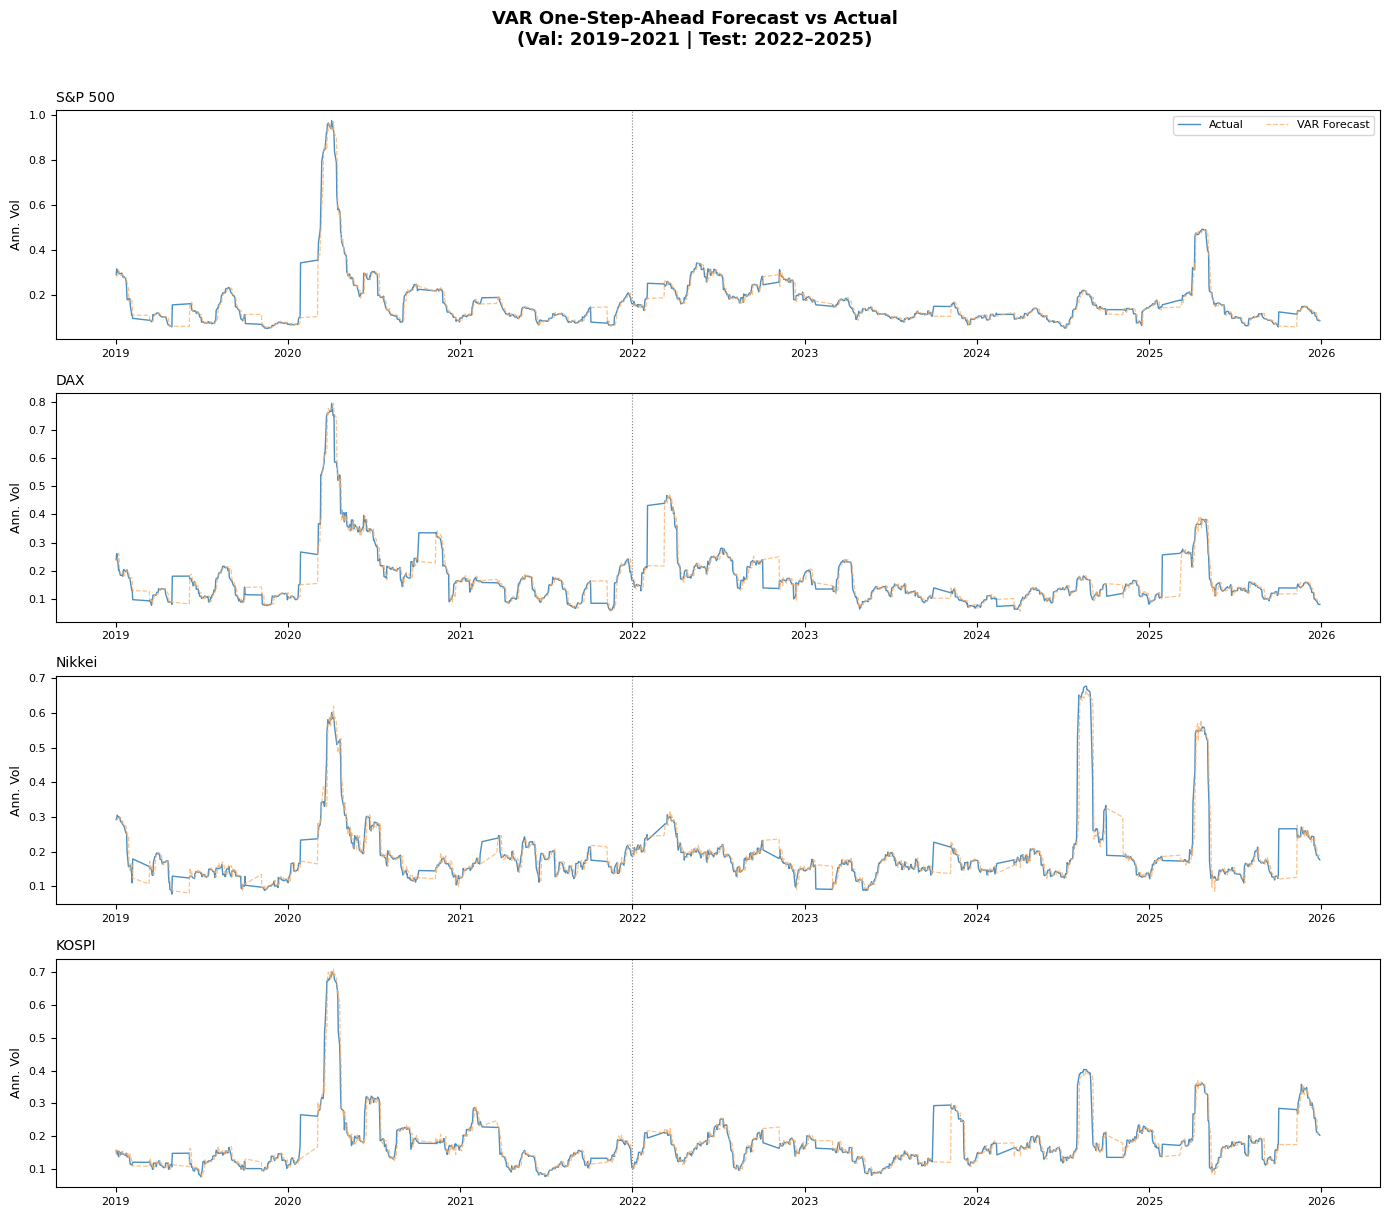

Saved → ..\outputs\figures\fig9_var_forecast.png


In [ ]:
PLOT_MARKETS  = ["SP500_vol", "DAX_vol", "Nikkei_vol", "KOSPI_vol"]
MARKET_LABELS = ["S&P 500", "DAX", "Nikkei", "KOSPI"]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
fig.suptitle("VAR One-Step-Ahead Forecast vs Actual\n(Val: 2019–2021 | Test: 2022–2025)",
             fontsize=13, fontweight="bold", y=1.01)

for ax, col, label in zip(axes, PLOT_MARKETS, MARKET_LABELS):
    ax.plot(act_v.index, act_v[col], color="#2c7bb6", lw=1.0, alpha=0.85, label="Actual")
    ax.plot(fc_v.index,  fc_v[col],  color="#fdae61", lw=0.9, alpha=0.75,
            linestyle="--", label="VAR Forecast")
    ax.plot(act_t.index, act_t[col], color="#2c7bb6", lw=1.0, alpha=0.85)
    ax.plot(fc_t.index,  fc_t[col],  color="#fdae61", lw=0.9, alpha=0.75, linestyle="--")
    ax.axvline(pd.Timestamp(TEST_START), color="gray", lw=0.8, linestyle=":")
    ax.set_ylabel("Ann. Vol", fontsize=9)
    ax.set_title(label, fontsize=10, loc="left")
    ax.tick_params(labelsize=8)
    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=8, ncol=3)

plt.tight_layout()
path = os.path.join(FIG_DIR, "fig11_var_forecast.png")
plt.savefig(path, dpi=150, bbox_inches="tight"); plt.show()
print(f"Saved → {path}")

---
**Next → `05b_tuning.ipynb`**